# Emotion Classification in Cartoon Faces (Tom & Jerry)

This notebook implements a basic image classification pipeline for detecting emotions in cartoon characters.

The pipeline includes:
- Face detection and dataset creation (preprocessed separately)
- Feature extraction: raw pixels, Sobel edges, Fourier transform, and spatial information
- Classification using a manually implemented K-Nearest Neighbors (KNN)
- Evaluation with accuracy, confusion matrix, and sample predictions

This notebook also visualizes preprocessing and feature extraction steps to show how the input images are enhanced and represented for classification.

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Constants
DATA_DIR = 'emotion_dataset'
IMG_SIZE = (32, 32)
MODEL_DIR = 'models'
K_NEIGHBORS = 4

## Preprocessing and Feature Extraction

Each image is preprocessed to enhance contrast and reduce noise:
- **Histogram Equalization**: improves contrast
- **Gaussian Blur**: smooths noise
- **Normalization**: scales pixel values to [0,1]

Features extracted from each image:
1. Raw pixels (baseline)
2. Sobel edge magnitude (local shape features)
3. Fourier transform magnitude (global frequency info)
4. Spatial region averages (4 quadrants)

In [2]:
def preprocess_image(image):
    """Apply light preprocessing to improve classification."""
    image = cv2.equalizeHist(image)           # Histogram equalization
    image = cv2.GaussianBlur(image, (3,3), 0) # Gaussian blur
    image = image.astype(np.float32) / 255.0  # Normalize 0-1
    return image

def extract_features(image):
    """Combine raw pixels with Sobel, Fourier, and spatial features."""
    features = []

    # Raw pixels
    raw_flat = image.flatten()
    features.extend(raw_flat)

    # Sobel edges
    sobel_x = cv2.Sobel(image, cv2.CV_32F, 1, 0)
    sobel_y = cv2.Sobel(image, cv2.CV_32F, 0, 1)
    sobel_flat = np.sqrt(sobel_x**2 + sobel_y**2).flatten()
    features.extend(sobel_flat)

    # Fourier transform
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.log(1 + np.abs(fshift))
    h, w = magnitude_spectrum.shape
    center = magnitude_spectrum[h//2 - 4:h//2 + 4, w//2 - 4:w//2 + 4]
    features.extend(center.flatten())

    # Spatial averages (4 quadrants)
    h2, w2 = image.shape[0]//2, image.shape[1]//2
    tl = np.mean(image[:h2, :w2])
    tr = np.mean(image[:h2, w2:])
    bl = np.mean(image[h2:, :w2])
    br = np.mean(image[h2:, w2:])
    features.extend([tl, tr, bl, br])

    return np.array(features, dtype=np.float32)

### Visualization Helper

Helps visualize the preprocessing and feature extraction results for a few sample images:
- Original grayscale image
- Preprocessed image
- Sobel edge magnitude
- Fourier magnitude spectrum
- Spatial region means overlay (optional)

In [3]:
def visualize_features(image, idx=0):
    """Show original, preprocessed, Sobel, Fourier magnitude for a sample image."""
    preprocessed = preprocess_image(image)

    # Sobel edges
    sobel_x = cv2.Sobel(preprocessed, cv2.CV_32F, 1, 0)
    sobel_y = cv2.Sobel(preprocessed, cv2.CV_32F, 0, 1)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

    # Fourier
    f = np.fft.fft2(preprocessed)
    fshift = np.fft.fftshift(f)
    fourier_mag = np.log(1 + np.abs(fshift))

    # Plot
    plt.figure(figsize=(12,3))
    plt.subplot(1,4,1)
    plt.imshow(image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(preprocessed, cmap='gray')
    plt.title('Preprocessed')
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title('Sobel Edges')
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(fourier_mag, cmap='gray')
    plt.title('Fourier Mag')
    plt.axis('off')

    plt.suptitle(f"Sample Image {idx}")
    plt.show()

## Loading Dataset and Visualizing Features

Visualizing the preprocessing and feature extraction of a few images from the dataset.

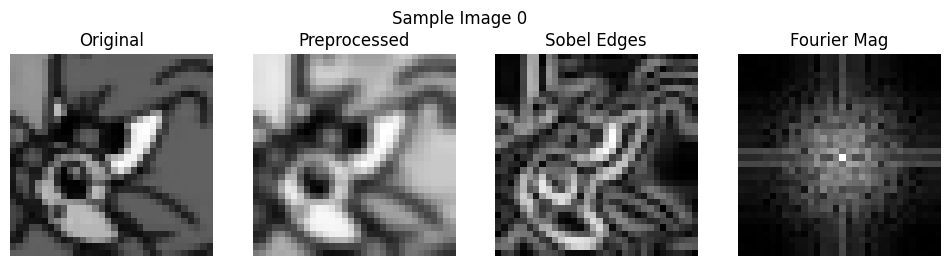

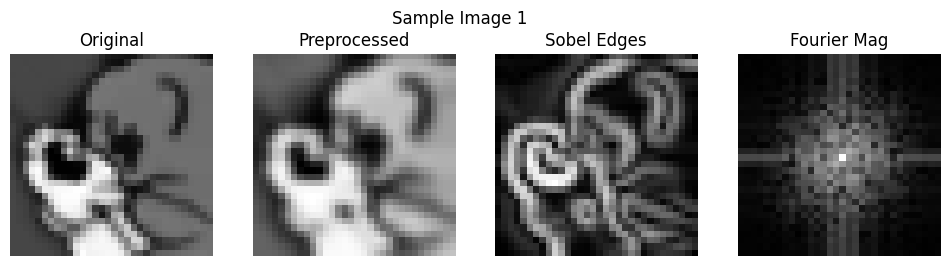

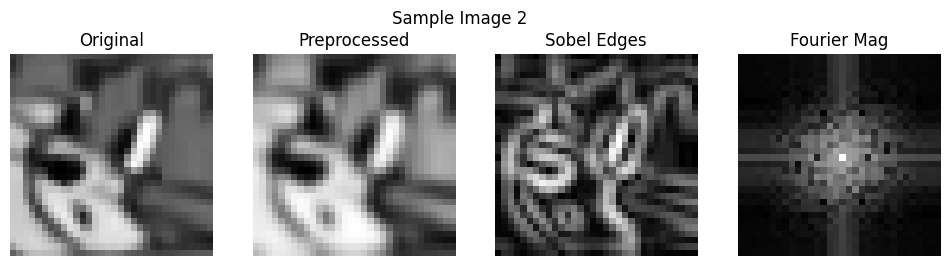

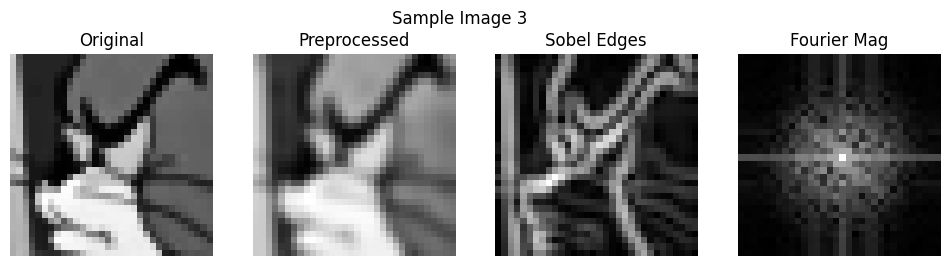

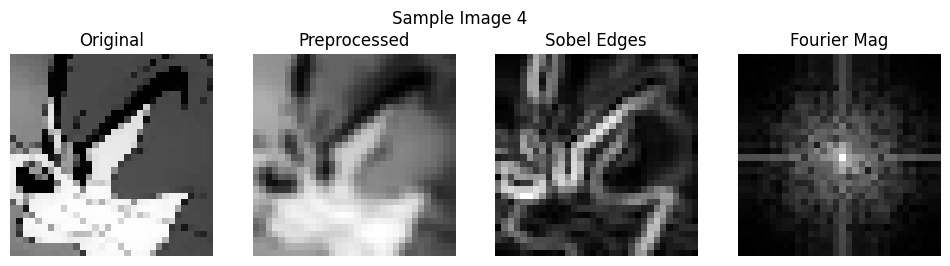

In [4]:
sample_images = []
sample_labels = []

all_label_names = sorted(
    [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
)

for label_name in all_label_names:
    folder = os.path.join(DATA_DIR, label_name)
    for i, filename in enumerate(os.listdir(folder)):
        if i >= 1: break  # Take only 1 image per class for visualization
        img_path = os.path.join(folder, filename)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is not None:
            image = cv2.resize(image, IMG_SIZE)
            sample_images.append(image)
            sample_labels.append(label_name)

# Visualize features for the first 5 images
for idx, img in enumerate(sample_images[:5]):
    visualize_features(img, idx=idx)

## Load Entire Dataset and Extract Features

In [5]:
def load_data():
    images = []
    labels = []

    label_to_index = {name: idx for idx, name in enumerate(all_label_names)}

    for label_name in all_label_names:
        folder = os.path.join(DATA_DIR, label_name)
        label_idx = label_to_index[label_name]

        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue
            image = cv2.resize(image, IMG_SIZE)
            preprocessed = preprocess_image(image)
            features = extract_features(preprocessed)

            images.append(features)
            labels.append(label_idx)

    return np.array(images), np.array(labels), all_label_names

print("Loading and processing full dataset...")
X_data, y_data, label_names = load_data()
print("Feature vector size:", X_data.shape[1])

Loading and processing full dataset...
Feature vector size: 2116


## Split Dataset and Train Manual KNN

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

def predict_knn(X_train, y_train, test_features, k_neighbors):
    distances = np.linalg.norm(X_train - test_features, axis=1)
    nearest_idx = np.argsort(distances)[:k_neighbors]
    nearest_labels = y_train[nearest_idx]
    unique, counts = np.unique(nearest_labels, return_counts=True)
    return unique[np.argmax(counts)]

# Predict on test set
y_pred = []
for test_feat in X_test:
    y_pred.append(predict_knn(X_train, y_train, test_feat, K_NEIGHBORS))

## Evaluate Model
- Overall accuracy
- Classification report (precision, recall, f1-score)
- Confusion matrix

Model Accuracy: 43.08%

Classification Report:
                 precision    recall  f1-score   support

    jerry_angry       0.00      0.00      0.00         2
    jerry_happy       0.40      0.33      0.36         6
jerry_surprised       0.78      0.58      0.67        12
      tom_angry       0.33      0.08      0.13        12
      tom_happy       0.38      0.74      0.50        19
  tom_surprised       0.44      0.29      0.35        14

       accuracy                           0.43        65
      macro avg       0.39      0.34      0.34        65
   weighted avg       0.45      0.43      0.40        65



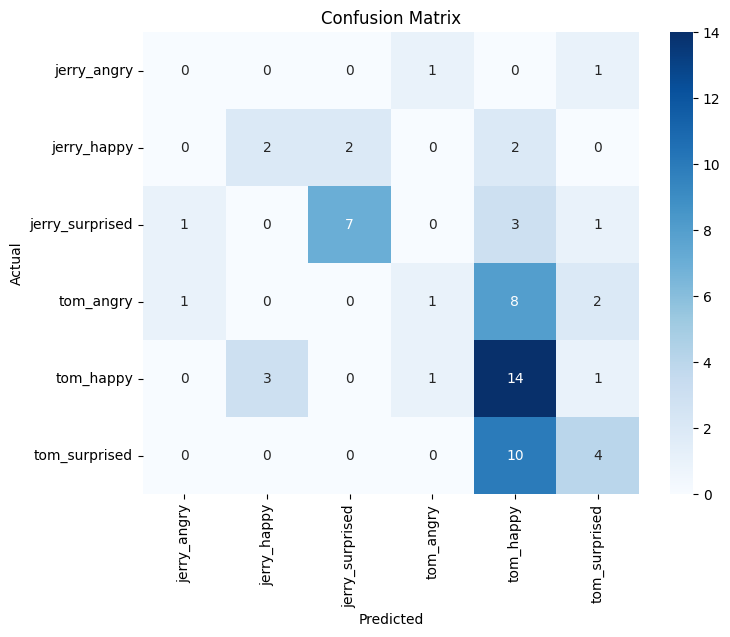

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Sample Predictions

Showing some test images with their predicted vs real labels to visually inspect model performance.

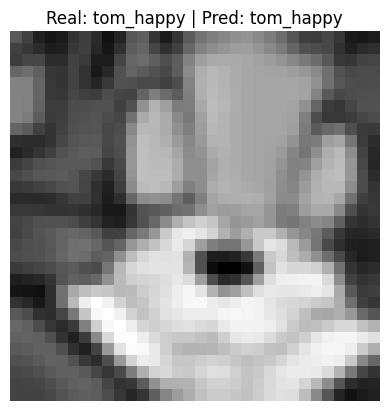

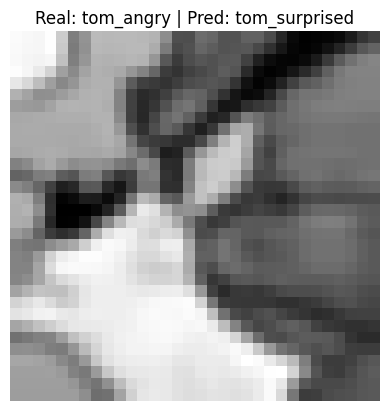

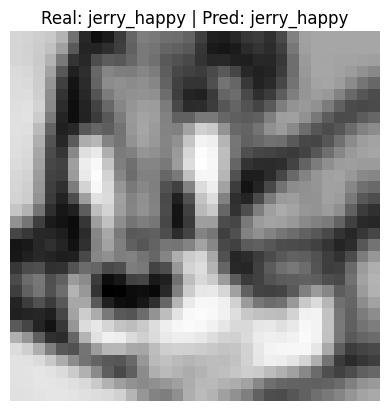

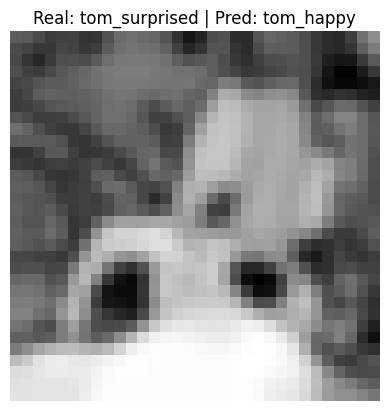

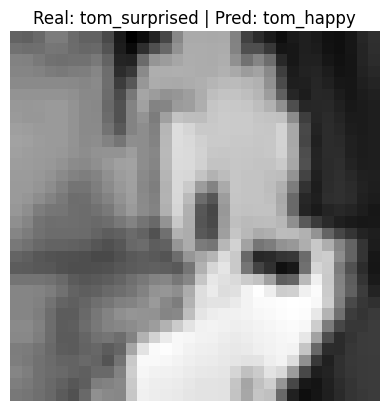

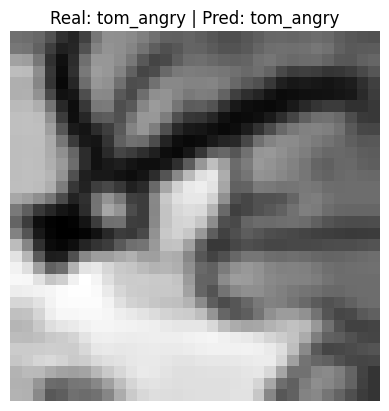

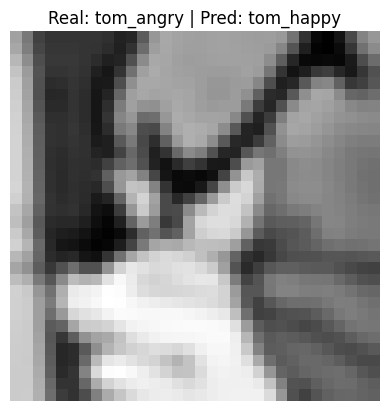

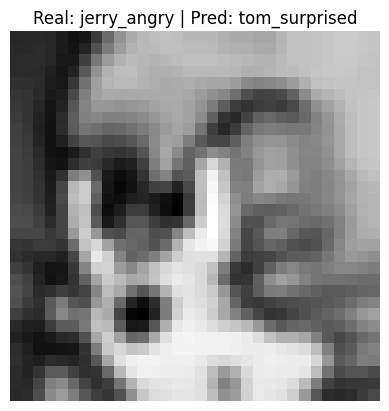

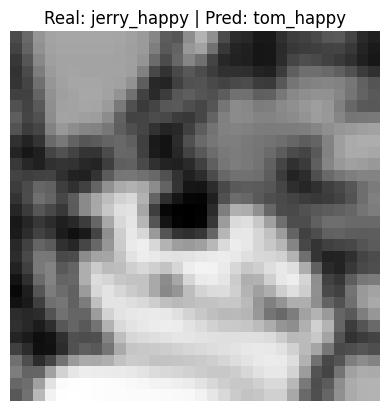

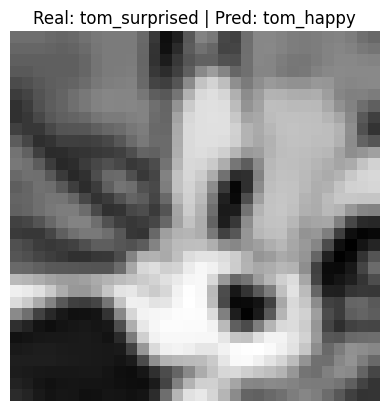

In [10]:
num_samples = min(10, len(X_test))

for i in range(num_samples):
    feat = X_test[i]

    # Reconstruct image from raw pixel features (first 32x32)
    raw_pixels = feat[:IMG_SIZE[0]*IMG_SIZE[1]].reshape(IMG_SIZE)

    plt.imshow(raw_pixels, cmap='gray')
    plt.title(f"Real: {label_names[y_test[i]]} | Pred: {label_names[y_pred[i]]}")
    plt.axis('off')
    plt.show()

## Save Model and Features

Saving the processed dataset and label mapping for future use or inference.

In [11]:
if not os.path.isdir(MODEL_DIR): os.mkdir(MODEL_DIR)

np.savez(os.path.join(MODEL_DIR, 'knn_data_enhanced.npz'), X_data=X_data, y_data=y_data)
joblib.dump(label_names, os.path.join(MODEL_DIR, 'knn_labels.pkl'))

print("Saved feature data and labels. Training complete!")

Saved feature data and labels. Training complete!
